In [31]:
#======================#
#   Import Libraries   #
#======================#

import ROOT
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import pandas as pd
from scipy.optimize import curve_fit

RUN = 3291

In [ ]:
#==================#
#   Data Loading   #
#==================#

# limit number of events to load
nmax = int(1e9)

f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/ROOT/run{RUN}.root")
rdf = ROOT.RDataFrame("DataR", f).Range(nmax)  # take up to nmax entries
events = rdf.AsNumpy(columns=["Channel", "Energy"])

Channel = events["Channel"]
Energy = events["Energy"]

# Perform the enegy smearing for the HPGe detector (Axel Boeltzig support, reported on Knoll book)
# Change each energy value by a random value uniformly distributed between -0.5 and 0.5 keV
Energy = Energy + np.random.uniform(-0.5, 0.5, size=len(Energy))

HPGe = Energy[Channel == 7]

print(f"Loaded {len(Channel):.2e} events (max {nmax})")

Loaded 1.11e+08 events (max 1000000000)


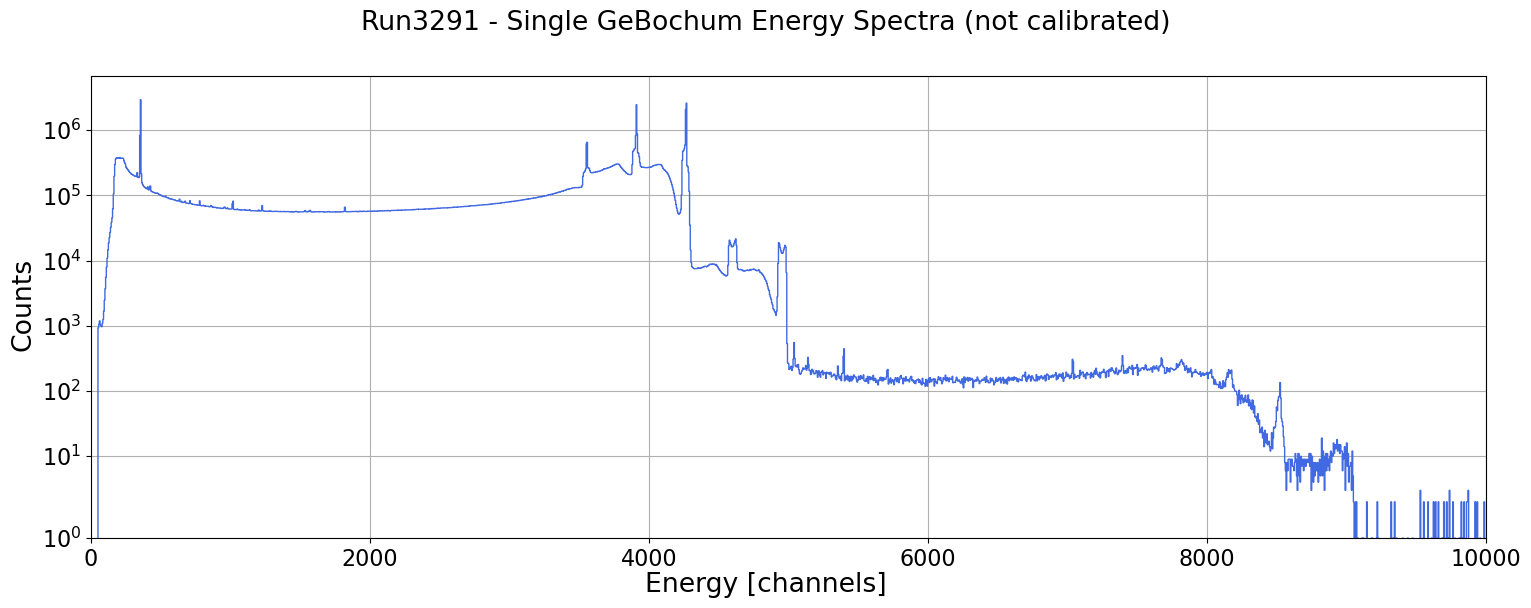

In [33]:
#===================================#
#   Plotting Uncalibrated Spectra   #
#===================================#

fig, ax = plt.subplots(1, 1, figsize=(18,6), sharex=True, sharey=True)

fig.suptitle(f"Run{RUN} - Single GeBochum Energy Spectra (not calibrated)", y=0.99)
fig.supxlabel("Energy [channels]", y=0.01)
fig.supylabel("Counts", x=0.08)
plt.yscale("symlog")

ax.hist(HPGe, bins=np.linspace(50, 10000, 2000), histtype='step', label="HPGe", color="royalblue")
ax.set_xlim(0, 10000)
ax.set_ylim(1, None)
ax.grid()

plt.subplots_adjust(hspace=0.18, wspace=0.03)

plt.show()

3291,HPGe,511.0,356.12
3291,HPGe,5106.0,3551.66
3291,HPGe,5617.0,3910.04
3291,HPGe,6128.0,4258.47


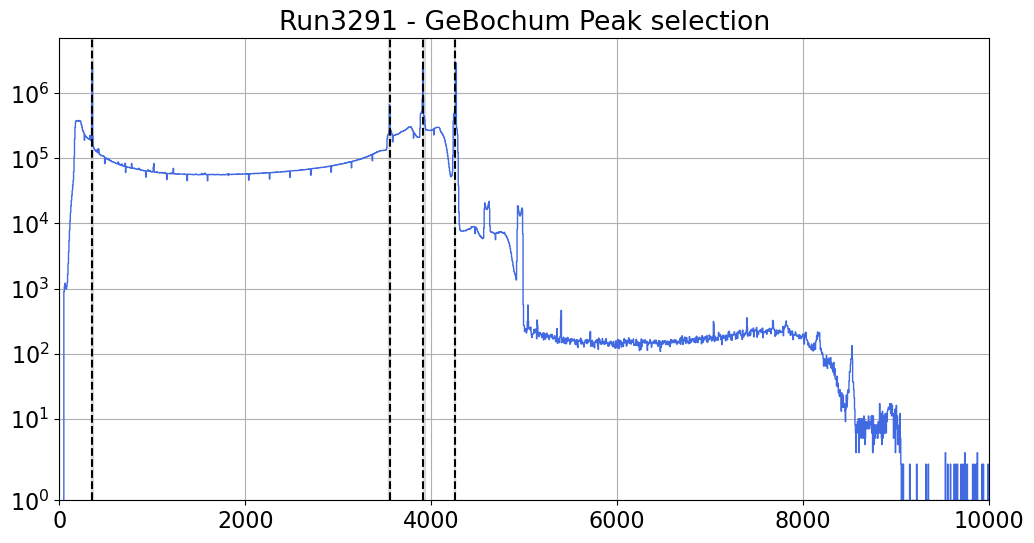

In [4]:
#=====================#
#   Peaks Selection   #
#=====================#

# Define base ROI centers for HPGe
base_values = np.array([350, 3550, 3920, 4250], dtype=float)

# Idx regions to be neglected
neglect = []

# ROI center for single HPGe crystal
ROI_center = base_values

if len(neglect) > 0:
    neg = np.array(neglect, dtype=int)
    mask = np.ones(ROI_center.size, dtype=bool)
    valid = neg[neg < ROI_center.size]
    if valid.size > 0:
        mask[valid] = False
    ROI_center = ROI_center[mask]

ROI_sigma = 250.0

Energies = np.array([511, 6128-511*2, 6128-511, 6128], dtype=float)  # keV

# remove energies at indices in neglect (handles multiple indices)
if len(neglect) > 0:
    Energies = np.delete(Energies, neglect)

def gauss_linearBKG(x, a, x0, sigma, m, q):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + m * np.log(x) + q

def gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Single-crystal HPGe peak selection
hpge_data = np.asarray(HPGe, dtype=float)

ax.set_title(f"Run{RUN} - GeBochum Peak selection")
ax.set_yscale("symlog")

hist = ax.hist(hpge_data, bins=np.linspace(50, 10000, 2000), histtype='step', lw=3, color="royalblue")
bin_centers = (hist[1][:-1] + hist[1][1:]) / 2
counts = hist[0]

# High-energy cut detection (consecutive window of 20 bins with mean < 1)
idx_start = np.searchsorted(bin_centers, 15000, side='right')
cut_val = 20000
if idx_start <= len(counts) - 20:
    for j in range(idx_start, len(counts) - 19):
        if counts[j:j+20].mean() < 1:
            cut_val = bin_centers[j]
            break
ax.axvline(cut_val, color='forestgreen', ls='--', lw=3)

# Peak fitting for each ROI
for idx, center in enumerate(ROI_center):
    if Energies[idx] < 10000:
        ROI_sigma_local = 10
    else:
        ROI_sigma_local = 800
    
    mask = (bin_centers >= center - ROI_sigma_local) & (bin_centers <= center + ROI_sigma_local)
    xdata = bin_centers[mask]
    ydata = counts[mask]

    ax.axvspan(center - ROI_sigma_local, center + ROI_sigma_local, color='grey', alpha=0.2)

    try:
        if xdata.size == 0 or ydata.size == 0:
            # Empty ROI: mark center as peak
            x0 = center
            ax.axvline(x0, color="black", linestyle='--')
            print(f"{RUN},HPGe,{Energies[idx]},{x0:.2f}")
            continue
        
        p0 = [ydata.max(), center, 60]
        popt, pcov = curve_fit(gauss, xdata, ydata, p0=p0, method='trf')
        amp, x0, sigma = popt
        
        # Validate fit result
        if amp <= 0 or sigma <= 0 or not (center - ROI_sigma_local <= x0 <= center + ROI_sigma_local) or sigma > ROI_sigma_local * 3:
            raise ValueError("Unreasonable fit result")

        x_fit = np.linspace(center - ROI_sigma_local, center + ROI_sigma_local, 1000)
        y_fit = gauss(x_fit, *popt)
        ax.plot(x_fit, y_fit, color="deeppink", lw=2)
        ax.axvline(x0, color="black", ls="--")

    except Exception:
        # Fallback to maximum bin if fitting fails
        x0 = xdata[np.argmax(ydata)] if xdata.size else center
        ax.axvline(x0, color="black", linestyle='--')

    print(f"{RUN},HPGe,{Energies[idx]},{x0:.2f}")

ax.set_xlim(0, 10000)
ax.set_ylim(1, None)
ax.grid()

plt.subplots_adjust(hspace=0.18, wspace=0.03)

plt.show()

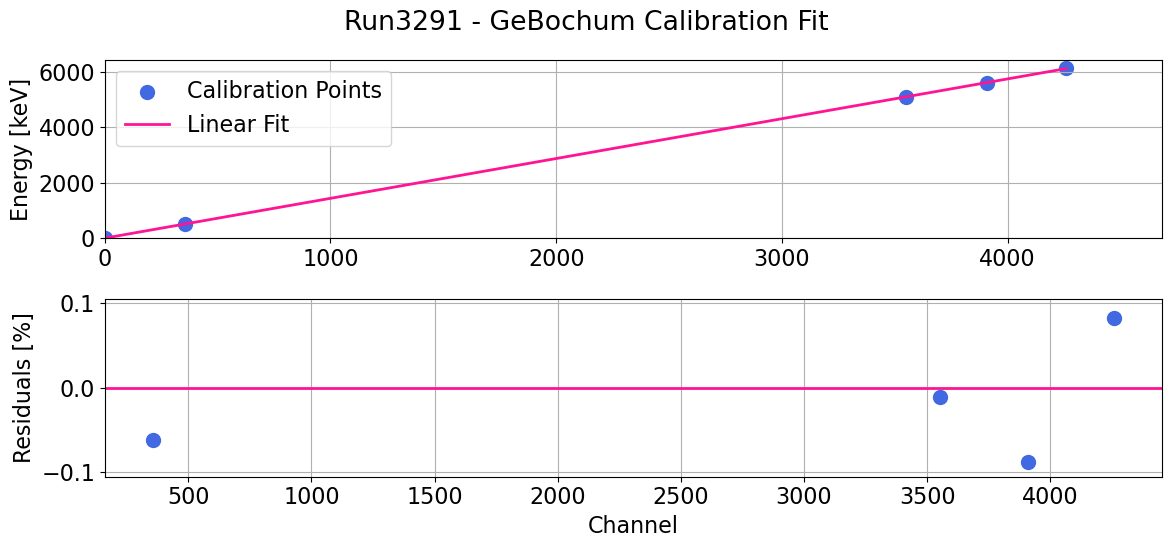

In [34]:
#=====================#
#   Calibration Fit   #
#=====================#

def linear(x, a, b):
    return a * x + b

df = pd.read_csv("/data0/biasissi/LUNA/19F+p_g+20Ne/Calibration/calibration_lines_hpge.csv", delimiter=",")
df = df[df["Run"] == RUN]

params = []

# original calibration points (Energy in keV)
Energy = df["Energy"].values
Channel = df["Channel"].values

# add the (0,0) calibration point
Channel = np.concatenate(([0], Channel))
Energy = np.concatenate(([0], Energy))

# fit linear to the augmented arrays
popt, pcov = curve_fit(linear, Channel, Energy)

# store parameters in keV units
params.append(popt)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 6))

fig.suptitle(f"Run{RUN} - GeBochum Calibration Fit", y=0.92)

# Top: calibration points (including (0,0)) and linear fit
ax0.scatter(Channel, Energy, color='royalblue', label='Calibration Points', s=100)
x_fit = np.linspace(0, np.max(Channel), 1000)
y_fit = linear(x_fit, *popt)
ax0.plot(x_fit, y_fit, color='deeppink', label='Linear Fit', lw=2)

ax0.set_ylabel("Energy [keV]")
ax0.set_xlim(0, np.max(Channel) * 1.1)
ax0.set_ylim(0, None)
ax0.grid()
ax0.legend()

# Bottom: relative residuals computed only on original points (exclude the artificial 0,0 to avoid div-by-zero)
mask = Energy != 0
if mask.sum() == 0:
    resid = np.zeros_like(Energy)
else:
    resid = (Energy[mask] - linear(Channel[mask], *popt)) / Energy[mask] * 100
ax1.scatter(Channel[mask], resid, color='royalblue', s=100)
ax1.axhline(0, color='deeppink', lw=2)

if resid.size:
    ax1.set_ylim(-np.max(np.abs(resid)) * 1.2, np.max(np.abs(resid)) * 1.2)
else:
    ax1.set_ylim(-1, 1)

ax1.set_xlabel("Channel")
ax1.set_ylabel("Residuals [%]")

ax1.grid()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [6]:
#===================================#
#   Generate the Calibration File   #
#===================================#

out_fname = f"Params/calibration_run{RUN}.txt"
with open(out_fname, "w") as f:
    f.write("0	0	1\n")
    for i, p in enumerate(params, start=1):
        # write params in opposite order (c,b,a) for quadratic a*x^2 + b*x + c
        f.write(f"{i}\t" + "\t".join(map(str, p[::-1])) + "\n")
    f.write("7	0	1")
print(f"Calibration file written: {out_fname}")

Calibration file written: Params/calibration_run3291.txt


344.50349199999994
327.1293717706802


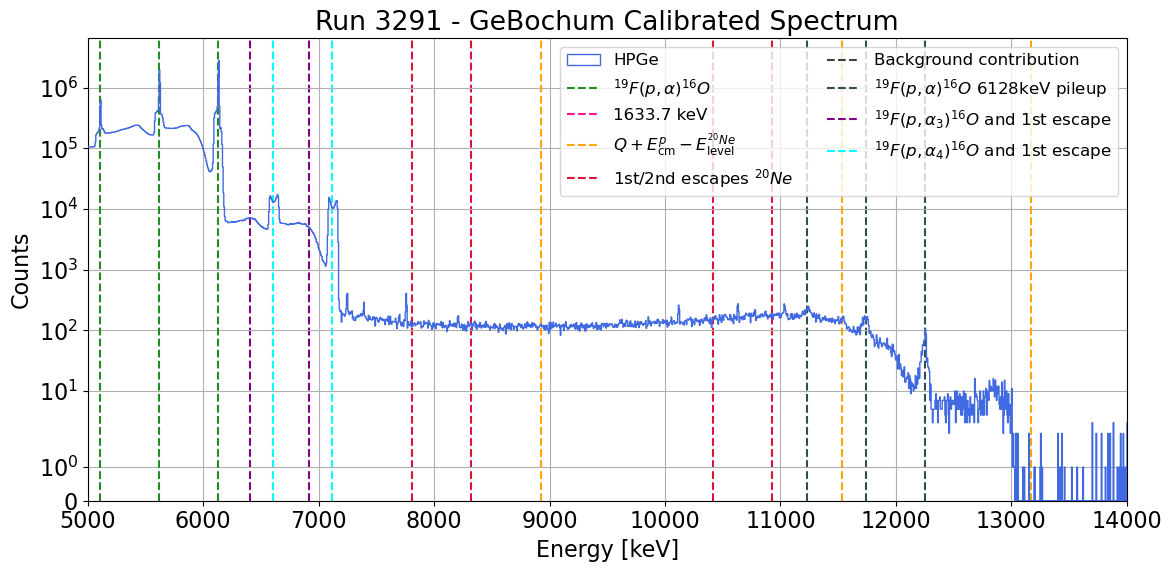

In [39]:
#=====================================#
#   Plot Calibrated HPGe Spectrum    #
#=====================================#

from matplotlib.patches import bbox_artist


levels_20ne = np.array([0, 1633.674, 4247.7], dtype=float)
Q = 12843.4581
# Ecm = 0.9933*(242.911 + 2547/1000)-0.41
Ecm = 0.9933*(345.900 + 1340/1000)-0.41
print(Ecm)
Ecm = Ecm * 18.998 /20.007
print(Ecm)

# Apply linear calibration to HPGe data
hpge_calibrated = linear(HPGe, *params[0])

plt.figure(figsize=(12, 6))

plt.title(f'Run {RUN} - GeBochum Calibrated Spectrum')
plt.yscale('symlog')

plt.hist(hpge_calibrated, bins=np.linspace(0, 30000, 1750*3), histtype='step', lw=2.5, color='royalblue', label='HPGe', zorder=100)

# Reference lines for known transitions
plt.axvline(6128-511*2, color="forestgreen", ls='--', label=r'${}^{19}F(p,\alpha){}^{16}O$')
plt.axvline(6128-511, color="forestgreen", ls='--')
plt.axvline(6128, color="forestgreen", ls='--')
plt.axvline(1633.674, color="deeppink", ls='--', label='1633.7 keV')

for E in levels_20ne:
    plt.axvline(Q+Ecm-E, color="orange", ls='--', label=r'$Q+E^p_\text{cm}-E^{{}^{20}Ne}_\text{level}$' if E == levels_20ne[0] else None)


plt.axvline(8826.886124678222-511, color="crimson", ls='--', zorder=0, label=r'1st/2nd escapes ${}^{20}Ne$')
plt.axvline(8826.886124678222-511*2, color="crimson", ls='--', zorder=0)
plt.axvline(11440.912124678223-511, color="crimson", ls='--', zorder=0)
plt.axvline(11440.912124678223-511*2, color="crimson", ls='--', zorder=0)
plt.axvline(1633.674-511, color="crimson", ls='--', zorder=0)

plt.axvline(295.2, color="black", ls='--', alpha=0.75, zorder=0, label='Background contribution')
plt.axvline(351.9, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(511.0, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(569.7, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(609.3, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(768.3, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(911.2, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(969.0, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1120.3, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1238.1, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1377.7, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1408.0, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1460.8, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1509.2, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1588.2, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1729.6, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1764.5, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1770.2, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(1847.4, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(2103.0, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(2118.5, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(2204.1, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(2447.7, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(2614.5, color="black", ls='--', alpha=0.75, zorder=0)
plt.axvline(583.2, color="black", ls='--', alpha=0.75, zorder=0) #208Tl
plt.axvline(477.6, color="black", ls='--', alpha=0.75, zorder=0) #7Be

plt.axvline(6128*2, color="darkslategrey", ls='--', zorder=0, label=r'${}^{19}F(p,\alpha){}^{16}O$ 6128keV pileup') # 19F(p,a) pileup and escapes
plt.axvline(6128*2-511, color="darkslategrey", ls='--', zorder=0)
plt.axvline(6128*2-511*2, color="darkslategrey", ls='--', zorder=0)

plt.axvline(6917.1, color="purple", ls='--', zorder=0, label=r'${}^{19}F(p,\alpha_3){}^{16}O$ and 1st escape') # 19F(p,a3)
plt.axvline(6917.1-511, color="purple", ls='--', zorder=0) # 19F(p,a3) first escape

plt.axvline(7116.9, color="cyan", ls='--', zorder=0) # 19F(p,a4)
plt.axvline(7116.9-511, color="cyan", ls='--', zorder=0, label=r'${}^{19}F(p,\alpha_4){}^{16}O$ and 1st escape') # 19F(p,a4)
# a3 @6917keV, a4 @7017keV, factor ~10 in S-factor with Ep=225keV, weighted average ~6935keV

plt.xlabel('Energy [keV]')
plt.ylabel('Counts')

plt.xlim(5000, 14000)
plt.ylim(0, None)

plt.grid()
plt.legend(loc='upper right', ncols=2, fontsize=12)

plt.tight_layout()

plt.savefig(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Calibration/3291gebo_low.png", dpi=300, bbox_inches='tight')
plt.show()